<a href="https://colab.research.google.com/github/workhendry20-creator/alkindo-profile/blob/main/Brazilian_E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install DuckDB untuk menjalankan SQL langsung di Colab
!pip install duckdb --quiet

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment siap!")

Environment siap!


In [18]:
import os

def list_files_in_directory(path):
    print(f"Listing files in: {path}")
    for root, dirs, files in os.walk(path):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name) + '/')

list_files_in_directory('/content/')


Listing files in: /content/
/content/.config/
/content/sample_data/
/content/.config/gce
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/active_config
/content/.config/.last_update_check.json
/content/.config/.last_survey_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/configurations/
/content/.config/logs/
/content/.config/configurations/config_default
/content/.config/logs/2026.08.18/
/content/.config/logs/2026.08.18/13.44.35.738632.log
/content/.config/logs/2026.08.18/13.44.50.769621.log
/content/.config/logs/2026.08.18/13.44.49.975155.log
/content/.config/logs/2026.08.18/13.43.53.675741.log
/content/.config/logs/2026.08.18/13.44.37.283866.log
/content/.config/logs/2026.08.18/13.44.18.622222.log
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/olist_orders_dataset.csv
/content/sample_data/olist_customers_da

**Apakah keterlambatan pengiriman berdampak langsung pada rating pembeli (Review Score)?**

In [15]:
!mv /*.csv /content/sample_data/

In [17]:
query_delay = """
SELECT
    CASE
        WHEN CAST(order_delivered_customer_date AS DATE) > CAST(order_estimated_delivery_date AS DATE) THEN 'Terlambat'
        ELSE 'Tepat Waktu'
    END AS status_pengiriman,
    COUNT(DISTINCT o.order_id) AS total_pesanan,
    ROUND(AVG(r.review_score), 2) AS avg_rating
FROM '/content/sample_data/olist_orders_dataset.csv' o
JOIN '/content/sample_data/olist_order_reviews_dataset.csv' r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY 1;
"""

df_delay = duckdb.query(query_delay).df()
print(df_delay)

  status_pengiriman  total_pesanan  avg_rating
0       Tepat Waktu          89443        4.29
1         Terlambat           6381        2.27


**Top 10 Kategori Produk berdasarkan Revenue**

In [19]:
query_category = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name) AS kategori,
    COUNT(DISTINCT oi.order_id) AS total_order,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.freight_value), 2) AS avg_freight
FROM '/content/sample_data/olist_order_items_dataset.csv' oi
JOIN '/content/sample_data/olist_products_dataset.csv' p ON oi.product_id = p.product_id
LEFT JOIN '/content/sample_data/product_category_name_translation.csv' t ON p.product_category_name = t.product_category_name
GROUP BY 1
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_category = duckdb.query(query_category).df()
print(df_category)

                kategori  total_order  total_revenue  avg_freight
0          health_beauty         8836     1258681.34        18.88
1          watches_gifts         5624     1205005.68        16.78
2         bed_bath_table         9417     1036988.68        18.42
3         sports_leisure         7720      988048.97        19.51
4  computers_accessories         6689      911954.32        18.82
5        furniture_decor         6449      729762.49        20.73
6             cool_stuff         3632      635290.85        22.14
7             housewares         5884      632248.66        20.99
8                   auto         3897      592720.11        21.88
9           garden_tools         3518      485256.46        22.77


**Analisis Metode Pembayaran & Nilai Transaksi**

In [20]:
query_payment = """
SELECT
    payment_type AS metode_pembayaran,
    COUNT(DISTINCT order_id) AS total_transaksi,
    ROUND(SUM(payment_value), 2) AS total_nilai_transaksi,
    ROUND(AVG(payment_value), 2) AS avg_transaksi
FROM '/content/sample_data/olist_order_payments_dataset.csv'
GROUP BY 1
ORDER BY total_transaksi DESC;
"""

df_payment = duckdb.query(query_payment).df()
print(df_payment)

  metode_pembayaran  total_transaksi  total_nilai_transaksi  avg_transaksi
0       credit_card            76505            12542084.19         163.32
1            boleto            19784             2869361.27         145.03
2           voucher             3866              379436.87          65.70
3        debit_card             1528              217989.79         142.57
4       not_defined                3                   0.00           0.00


/tmp/ipykernel_6568/954647310.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_delay, x='status_pengiriman', y='avg_rating', ax=axes[0], palette=['#E74C3C', '#2ECC71'])
/tmp/ipykernel_6568/954647310.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_category, x='total_revenue', y='kategori', ax=axes[1], palette='Blues_r')


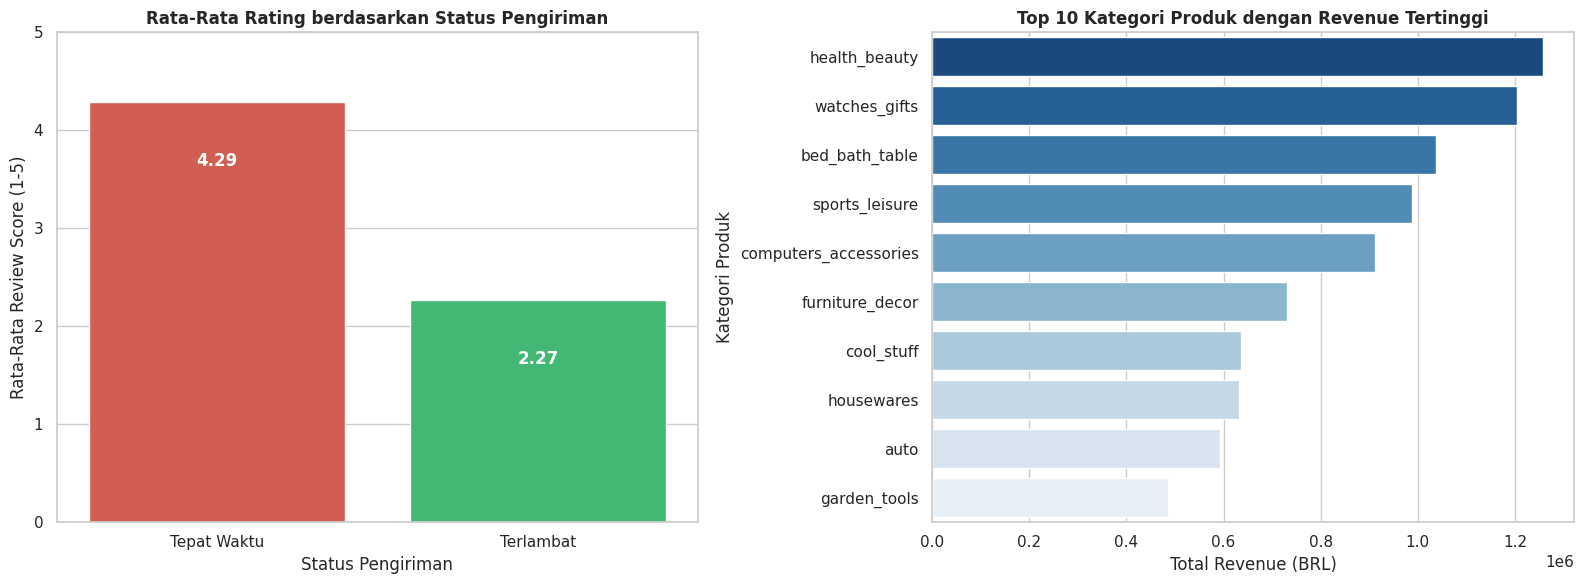

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Dampak Keterlambatan Pengiriman terhadap Review Score
sns.barplot(data=df_delay, x='status_pengiriman', y='avg_rating', ax=axes[0], palette=['#E74C3C', '#2ECC71'])
axes[0].set_title('Rata-Rata Rating berdasarkan Status Pengiriman', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Status Pengiriman')
axes[0].set_ylabel('Rata-Rata Review Score (1-5)')
axes[0].set_ylim(0, 5)

# Menambahkan angka statistik di atas batang
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2., p.get_height() - 0.6),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Grafik 2: Top 10 Kategori Produk berdasarkan Total Revenue
sns.barplot(data=df_category, x='total_revenue', y='kategori', ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 10 Kategori Produk dengan Revenue Tertinggi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].set_ylabel('Kategori Produk')

plt.tight_layout()
plt.show()

**Advanced SQL Query (RFM Segmentation)**

In [22]:
query_rfm = """
WITH max_date AS (
    -- 1. Cari tanggal transaksi terakhir di seluruh database sebagai titik acuan
    SELECT MAX(CAST(order_purchase_timestamp AS TIMESTAMP)) AS ref_date
    FROM '/content/sample_data/olist_orders_dataset.csv'
    WHERE order_status = 'delivered'
),
raw_rfm AS (
    -- 2. Hitung R, F, dan M per customer_unique_id
    SELECT
        c.customer_unique_id,
        MAX(CAST(o.order_purchase_timestamp AS TIMESTAMP)) AS last_order_date,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(p.payment_value) AS monetary
    FROM '/content/sample_data/olist_orders_dataset.csv' o
    JOIN '/content/sample_data/olist_customers_dataset.csv' c ON o.customer_id = c.customer_id
    JOIN '/content/sample_data/olist_order_payments_dataset.csv' p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_metrics AS (
    -- 3. Hitung selisih hari (Recency)
    SELECT
        r.customer_unique_id,
        DATE_DIFF('day', r.last_order_date, m.ref_date) AS recency_days,
        r.frequency,
        ROUND(r.monetary, 2) AS monetary
    FROM raw_rfm r
    CROSS JOIN max_date m
),
rfm_scores AS (
    -- 4. Beri skor 1-4 menggunakan Window Function NTILE
    SELECT
        *,
        NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
    FROM rfm_metrics
)
-- 5. Klasifikasikan ke segmen bisnis berdasarkan kombinasi skor
SELECT
    customer_unique_id,
    recency_days,
    frequency,
    monetary,
    r_score, f_score, m_score,
    CASE
        WHEN r_score = 4 AND m_score = 4 THEN 'Champions (Sangat Loyal & High Spender)'
        WHEN r_score >= 3 AND m_score >= 3 THEN 'Loyal Customers'
        WHEN r_score >= 3 AND m_score < 3 THEN 'Promising / New Customers'
        WHEN r_score <= 2 AND m_score >= 3 THEN 'At-Risk (High Value, Mulai Churn)'
        ELSE 'Hibernating / Lost Customers'
    END AS customer_segment
FROM rfm_scores;
"""

df_rfm = duckdb.query(query_rfm).df()
print("Jumlah Pelanggan Teranalisis:", len(df_rfm))
df_rfm.head(10)

Jumlah Pelanggan Teranalisis: 93357


,customer_unique_id,recency_days,frequency,monetary,r_score,f_score,m_score,customer_segment
0,317cfc692e3f86c45c95697c61c853a6,4,1,9.59,4,4,1,Promising / New Customers
1,bd06ce0e06ad77a7f681f1a4960a3cc6,350,1,10.07,1,1,1,Hibernating / Lost Customers
2,b33336f46234b24a613ad9064d13106d,69,1,10.89,4,4,1,Promising / New Customers
3,6f5b9d1cdccc4d28f0483a612edecacf,361,1,11.63,1,1,1,Hibernating / Lost Customers
4,2878e5b88167faab17d4fb83a986d38b,304,1,11.63,2,2,1,Hibernating / Lost Customers
5,809ca96e9696b9be5f69cd7ae803049d,459,1,12.28,1,1,1,Hibernating / Lost Customers
6,7859a40482024a3d00041c4ca1434298,90,1,12.39,4,4,1,Promising / New Customers
7,defbae0ddd4aeca563944124fbcc4bae,443,1,12.89,1,1,1,Hibernating / Lost Customers
8,a2cab25fa1a8a53ba04f8e7a78594b32,98,1,12.89,4,4,1,Promising / New Customers
9,3ee6e9979973bf7bf53518c4978cbae1,99,1,13.29,4,4,1,Promising / New Customers


**Ringkasan Statistik Segmen (SQL Aggregation)**

In [23]:
query_rfm_summary = """
SELECT
    customer_segment,
    COUNT(customer_unique_id) AS total_customers,
    ROUND(AVG(recency_days), 1) AS avg_recency_days,
    ROUND(AVG(monetary), 2) AS avg_spend,
    ROUND(SUM(monetary), 2) AS total_revenue
FROM df_rfm
GROUP BY customer_segment
ORDER BY total_revenue DESC;
"""

df_rfm_summary = duckdb.query(query_rfm_summary).df()
print(df_rfm_summary)

                          customer_segment  total_customers  avg_recency_days  \
0        At-Risk (High Value, Mulai Churn)            22831             363.2   
1                          Loyal Customers            17869             129.1   
2  Champions (Sangat Loyal & High Spender)             5978              58.0   
3             Hibernating / Lost Customers            23848             364.1   
4                Promising / New Customers            22831             111.4   

   avg_spend  total_revenue  
0     267.71     6112044.83  
1     220.45     3939233.96  
2     402.08     2403619.17  
3      63.97     1525671.22  
4      63.16     1441892.59  


/tmp/ipykernel_6568/749902789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6568/749902789.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


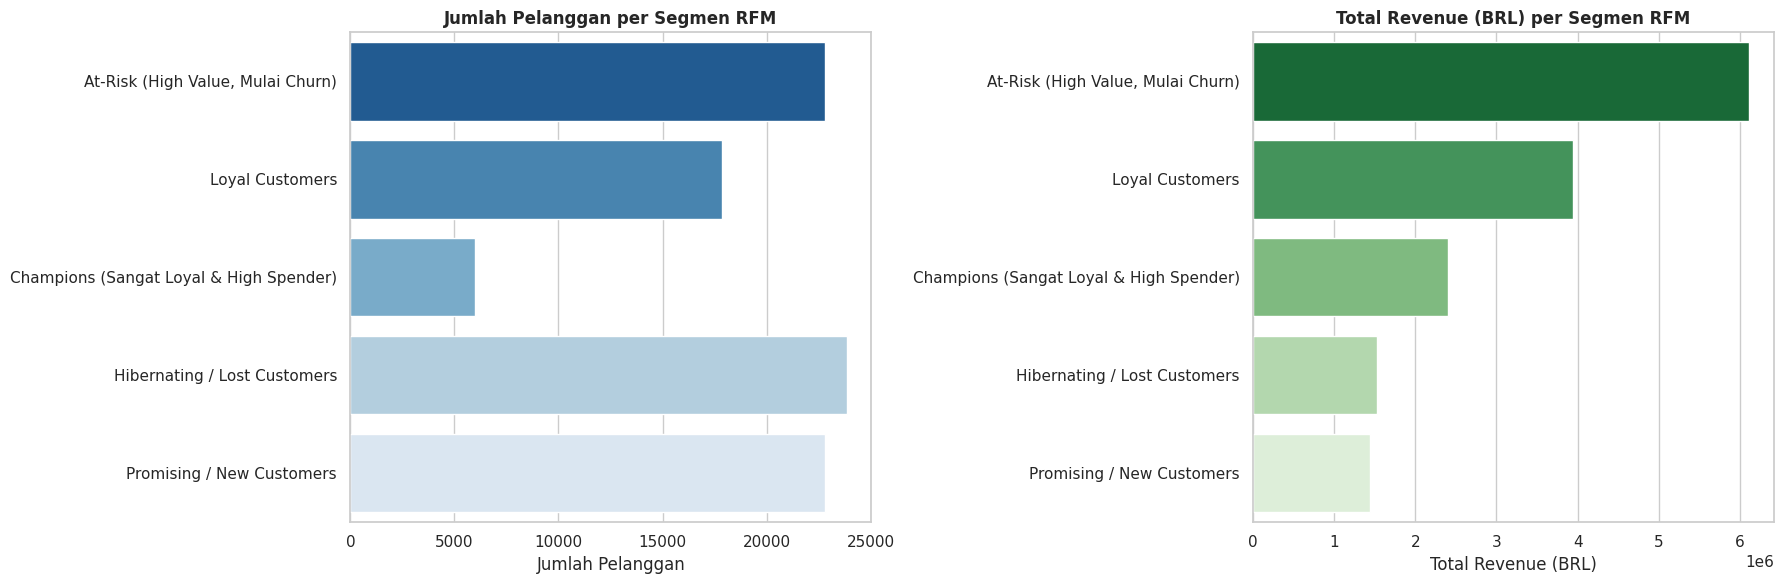

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisasi 1: Total Pelanggan per Segmen
sns.barplot(
    data=df_rfm_summary,
    y='customer_segment',
    x='total_customers',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Jumlah Pelanggan per Segmen RFM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].set_ylabel('')

# Visualisasi 2: Total Revenue per Segmen
sns.barplot(
    data=df_rfm_summary,
    y='customer_segment',
    x='total_revenue',
    ax=axes[1],
    palette='Greens_r'
)
axes[1].set_title('Total Revenue (BRL) per Segmen RFM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()